# ARIA - LITE

ARIA Lite is a lightweight GraphRAG-based biomedical research assistant focused on breast cancer AI literature.

The project combines two retrieval paradigms:

1. Semantic Retrieval
   Dense vector embeddings are used to retrieve papers semantically related to a user query.

2. Graph-Based Retrieval
   Biomedical entities such as genes and drugs are extracted from papers and represented as relationships in a lightweight knowledge graph.

By combining these two approaches, the system aims to provide more grounded and explainable retrieval compared to traditional vector-only RAG systems.

The project is intentionally scoped for rapid iteration and learning:
- ~300-500 PubMed papers
- Abstract-only corpus
- Lightweight graph construction
- Citation-grounded responses

Core technologies:
- PubMed / Entrez API
- SciSpacy
- Sentence Transformers
- FAISS
- Python + Google Colab

End Goal:
Build a small but functional biomedical GraphRAG system capable of retrieving relevant breast cancer AI papers and generating grounded answers with PMID citations.

# 4_graph_builder.ipynb

PURPOSE:
Build a unified biomedical GraphRAG-style knowledge graph from PubMed papers.

This graph combines semantic, grounding, and concept-level relationships to support retrieval and reasoning over biomedical literature.

This graph supports:

1. Section → Entity grounding (core knowledge extraction)
   - Links paper sections to biomedical entities (MENTIONS edges)
   - Provides grounded context for every entity occurrence in text

2. Entity ↔ Entity relations (concept graph layer)
   - Hard-rule biomedical relations derived from section context
   - Fallback CO_OCCURS edges for weak contextual association
   - Captures both structured and weak semantic relationships between entities

3. Section ↔ Section similarity (semantic document graph)
   - Built using SPECTER embeddings of section text
   - Connects semantically similar paper sections
   - Enables neighborhood-based retrieval across papers

4. Node representations (embedding layer)
   - Section nodes: SPECTER embeddings (text semantics)
   - Entity nodes: averaged embeddings from connected sections

This is the core graph layer for ARIA-Lite.
It is a hybrid semantic + symbolic biomedical graph designed for explainable retrieval and reasoning.


In [ ]:
# ============================================================
# SECTION 1 — Install Libraries
# ============================================================

!pip install networkx

In [ ]:
# ============================================================
# SECTION 2 — Imports
# ============================================================

from google.colab import drive
import os
import json
import networkx as nx
from collections import defaultdict
from tqdm import tqdm
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# ============================================================
# SECTION 3 — Graph Configuration
# ============================================================

GRAPH_CONFIG = {
    "enable_paper_similarity": True,   # V2 feature toggle
    "min_entity_overlap": 1,           # threshold for linking papers
}

In [ ]:
# ============================================================
# SECTION 4 — Project Paths and data loading
# ============================================================

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite_v2"

PAPER_FILE_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "structured_papers.json")
ENTITY_FILE_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "clean_papers_with_entities.json")
GRAPH_FILE_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "aria_lite_graph_v2_1.pkl") # Path to save graph

with open(PAPER_FILE_PATH, "r") as f:
    papers = json.load(f)

with open(ENTITY_FILE_PATH, "r") as f:
    entities = json.load(f)

print(f"Papers loaded: {len(papers)}")
print(f"Entity records loaded: {len(entities)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Papers loaded: 475
Entity records loaded: 1079


In [ ]:
# ============================================================
# SECTION 5 — Normalize Helper
# ============================================================

def normalize(text):
    return text.lower().strip()

In [ ]:
# ============================================================
# SECTION 6 — Build Section → Entity Mapping
# ============================================================

section_to_entities = {}

for section_id, ent_list in entities.items():

    seen = set()

    clean_entities = set()

    for item in ent_list:

        entity = item.get(
            "entity",
            ""
        )

        entity = normalize(entity)

        if not entity:
            continue

        # deduplicate
        if entity in seen:
            continue

        seen.add(entity)

        clean_entities.add(entity)

    section_to_entities[
        section_id
    ] = list(clean_entities)

print(
    "Section → Entity mapping built"
)

Section → Entity mapping built


In [ ]:
# ============================================================
# SECTION 7.0 — Initialize Graph and Add Section Nodes + Embeddings
# ============================================================

G = nx.Graph()

section_id_to_text = {}
section_ids = []
corpus = []

for paper in papers:

    pmid = paper["pmid"]
    title = paper["title"]
    sections = paper.get("sections", [])

    for section in sections:

        section_id = section["section_id"]
        text = section["text"]

        section_ids.append(section_id)
        corpus.append(text)

        section_id_to_text[section_id] = text

        G.add_node(
            section_id,
            type="section",
            pmid=pmid,
            title=title,
            section_type=section["section_type"],
            text=text,
            embedding=None  # placeholder (filled later)
        )

print("Section nodes added")


# ============================================================
# SECTION 7.1 — Compute embeddings
# ============================================================

from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("allenai-specter")

section_embeddings = model.encode(
    corpus,
    show_progress_bar=True,
    normalize_embeddings=True
)

section_embeddings = np.array(section_embeddings)


# ============================================================
# SECTION 7.2 — Attach embeddings to nodes
# ============================================================

for idx, section_id in enumerate(section_ids):

    G.nodes[section_id]["embedding"] = section_embeddings[idx]

print("Embeddings attached to section nodes")

Section nodes added


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/allenai-specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Embeddings attached to section nodes


In [ ]:
# ============================================================
# SECTION 8 — Add Entity Nodes + Section → Entity Edges
# ============================================================

entity_to_sections = defaultdict(set)

for section_id, ents in section_to_entities.items():

    for ent in ents:

        # entity node (ensure it exists once)
        if not G.has_node(ent):
            G.add_node(ent, type="entity", embedding=None)

        # section → entity edge
        G.add_edge(section_id, ent, type="MENTIONS")

        # build reverse index for embeddings later
        entity_to_sections[ent].add(section_id)

print("Entity nodes and MENTIONS edges added")


# ============================================================
# SECTION 8.1 — Compute entity embeddings
# ============================================================

import numpy as np

entity_embeddings = {}

for ent, sids in entity_to_sections.items():

    vectors = []

    for sid in sids:
        emb = G.nodes[sid].get("embedding")

        if emb is not None:
            vectors.append(emb)

    if len(vectors) > 0:
        entity_embeddings[ent] = np.mean(vectors, axis=0)
    else:
        entity_embeddings[ent] = None


# ============================================================
# SECTION 8.2 — Attach embeddings to entity nodes
# ============================================================

for ent, emb in entity_embeddings.items():

    if emb is not None:
        G.nodes[ent]["embedding"] = emb

print("Entity embeddings attached to graph")

Entity nodes and MENTIONS edges added
Entity embeddings attached to graph


In [ ]:
# ============================================================
# SECTION 9 — Hybrid Entity ↔ Entity Edges
# Hard Rules + CO_OCCURS fallback
# ============================================================

from collections import defaultdict
import itertools

# ------------------------------------------------------------
# Load linked entities
# ------------------------------------------------------------

with open(ENTITY_FILE_PATH, "r") as f:
    linked_entities = json.load(f)

# ------------------------------------------------------------
# Relation rules
# ------------------------------------------------------------

RELATION_RULES = {
    "BACKGROUND": [
        (("DISEASE", "ML_METHOD"), "STUDIED_WITH"),
        (("DISEASE", "CELL"), "INVOLVES"),
        (("DISEASE", "ORGANISM"), "AFFECTS"),
        (("DISEASE", "CHEMICAL"), "ASSOCIATED_WITH"),
    ],

    "METHODS": [
        (("ML_METHOD", "ML_METHOD"), "COMPARED_WITH"),
        (("ML_METHOD", "DISEASE"), "APPLIED_TO"),
        (("ML_METHOD", "CHEMICAL"), "USES"),
    ],

    "RESULTS": [
        (("ML_METHOD", "DISEASE"), "PREDICTS"),
        (("CHEMICAL", "DISEASE"), "BIOMARKER_FOR"),
        (("CELL", "DISEASE"), "ASSOCIATED_WITH"),
    ],

    "CONCLUSIONS": [
        (("ML_METHOD", "DISEASE"), "IMPACTS"),
        (("CHEMICAL", "DISEASE"), "IMPACTS"),
        (("CELL", "DISEASE"), "IMPACTS"),
    ]
}

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def get_section_type(section_key):
    return section_key.split("_")[-1]

def add_edge(a, b, rel_type, section_type, weight=1.0):
    """
    Safe edge adder (prevents duplication override issues)
    """

    if G.has_edge(a, b):

        # If edge exists, upgrade only if stronger relation appears
        existing = G[a][b]

        if existing.get("type") == "CO_OCCURS" and rel_type != "CO_OCCURS":
            # overwrite weak with strong
            G[a][b]["type"] = rel_type
            G[a][b]["section_type"] = section_type
            G[a][b]["weight"] = weight
    else:
        G.add_edge(
            a,
            b,
            type=rel_type,
            section_type=section_type,
            weight=weight
        )

# ------------------------------------------------------------
# Track rule-matched pairs (so CO_OCCURS doesn't duplicate)
# ------------------------------------------------------------

rule_matched_pairs = set()

# ------------------------------------------------------------
# STEP 1 — Apply HARD RULES
# ------------------------------------------------------------

for section_key, entities in linked_entities.items():

    section_type = get_section_type(section_key)

    if section_type not in RELATION_RULES:
        continue

    rules = RELATION_RULES[section_type]

    typed_entities = defaultdict(list)

    for ent in entities:
        label = ent.get("label")
        name = ent.get("entity")

        if name and label:
            typed_entities[label].append(name)

    for (type_a, type_b), relation in rules:

        group_a = typed_entities.get(type_a, [])
        group_b = typed_entities.get(type_b, [])

        if len(group_a) == 0 or len(group_b) == 0:
            continue

        # same-type pairs
        if type_a == type_b:

            for a, b in itertools.combinations(set(group_a), 2):

                pair = tuple(sorted([a, b]))
                rule_matched_pairs.add(pair)

                add_edge(
                    a, b,
                    relation,
                    section_type,
                    weight=0.9
                )

        # cross-type pairs
        else:

            for a in set(group_a):
                for b in set(group_b):

                    pair = (a, b)
                    rule_matched_pairs.add(pair)

                    add_edge(
                        a, b,
                        relation,
                        section_type,
                        weight=0.9
                    )

# ------------------------------------------------------------
# STEP 2 — CO_OCCURS fallback (ONLY if no rule applied)
# ------------------------------------------------------------

entity_graph = defaultdict(int)

for ents in section_to_entities.values():

    ents = list(set(ents))

    for i in range(len(ents)):
        for j in range(i + 1, len(ents)):

            a, b = sorted([ents[i], ents[j]])

            if (a, b) in rule_matched_pairs:
                continue  # skip if strong rule already exists

            entity_graph[(a, b)] += 1

# normalize weights
if len(entity_graph) > 0:
    max_w = max(entity_graph.values())
else:
    max_w = 1

for (a, b), w in entity_graph.items():

    add_edge(
        a, b,
        "CO_OCCURS",
        "GLOBAL",
        weight=w / max_w
    )

print("Hybrid hard-rule + CO_OCCURS graph built")

Hybrid hard-rule + CO_OCCURS graph built


In [ ]:
# ============================================================
# SECTION 10 — Section ↔ Section Similarity (FROM NODE EMBEDDINGS)
# ============================================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Extract embeddings from graph nodes
# ------------------------------------------------------------

embeddings = []
valid_section_ids = []

for sid in section_ids:

    emb = G.nodes[sid].get("embedding")

    if emb is not None:

        embeddings.append(emb)
        valid_section_ids.append(sid)

embeddings = np.array(embeddings)

# ------------------------------------------------------------
# Compute similarity matrix
# ------------------------------------------------------------

similarity_matrix = cosine_similarity(embeddings)

# ------------------------------------------------------------
# Add edges
# ------------------------------------------------------------

threshold = 0.9

n = len(valid_section_ids)

for i in range(n):
    for j in range(i + 1, n):

        sim = similarity_matrix[i][j]

        if sim > threshold:

            G.add_edge(
                valid_section_ids[i],
                valid_section_ids[j],
                type="SIMILAR_SECTION",
                weight=float(sim)
            )

print("Section similarity edges added using node embeddings")

Section similarity edges added using node embeddings


In [ ]:
# ============================================================
# SECTION 11 — Graph Summary (ENHANCED)
# ============================================================

from collections import defaultdict

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# -----------------------------
# Edge type breakdown
# -----------------------------
edge_types = defaultdict(int)

for _, _, data in G.edges(data=True):
    edge_types[data.get("type", "UNKNOWN")] += 1

print("\nEdge types:")
for k, v in edge_types.items():
    print(k, v)

# -----------------------------
# Node type breakdown (NEW)
# -----------------------------
node_types = defaultdict(int)

for node, data in G.nodes(data=True):
    node_types[data.get("type", "UNKNOWN")] += 1

print("\nNode types:")
for k, v in node_types.items():
    print(k, v)

Nodes: 2105
Edges: 22506

Edge types:
MENTIONS 6344
SIMILAR_SECTION 1467
STUDIED_WITH 46
COMPARED_WITH 382
USES 106
APPLIED_TO 150
PREDICTS 130
IMPACTS 25
CO_OCCURS 13577
INVOLVES 28
AFFECTS 49
ASSOCIATED_WITH 128
BIOMARKER_FOR 74

Node types:
section 1135
entity 970


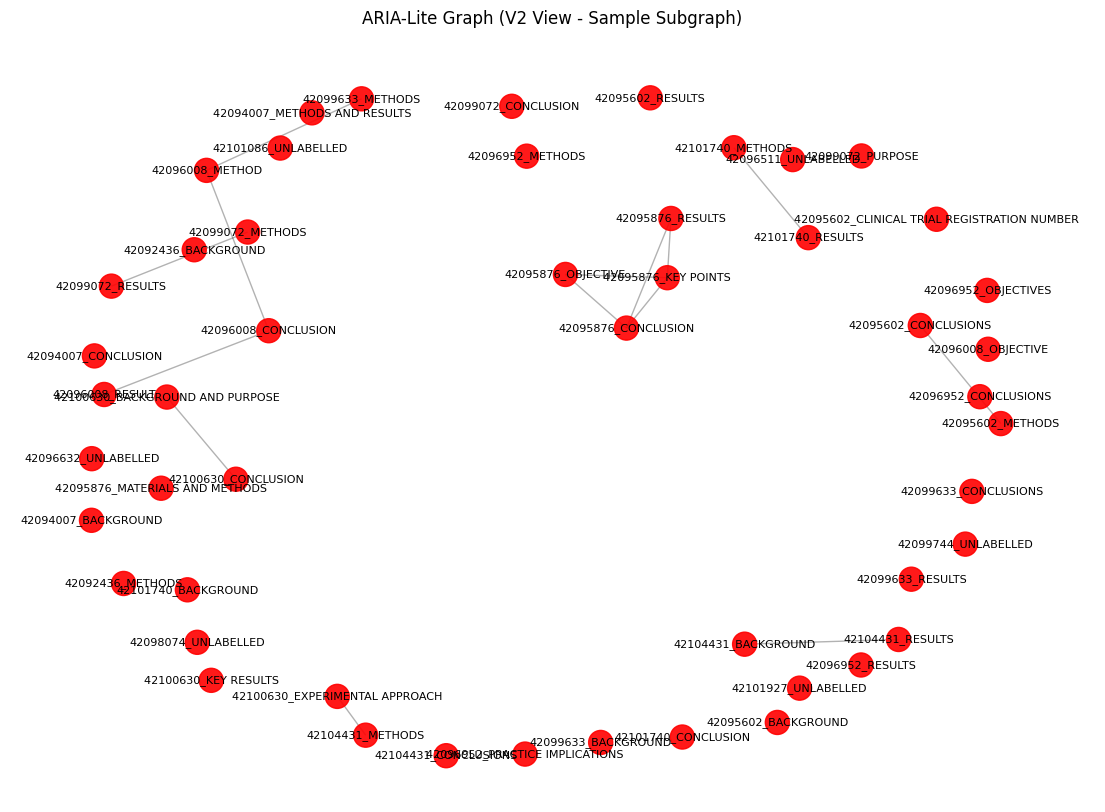

In [ ]:
# ============================================================
# SECTION 12 - GRAPH VISUALIZATION (SANITY CHECK)
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx

# -----------------------------
# Step 1: Sample subgraph (important for readability)
# -----------------------------
sample_nodes = list(G.nodes())[:50]  # adjust size if needed
subG = G.subgraph(sample_nodes)

# -----------------------------
# Step 2: Assign node colors
# -----------------------------
node_colors = []

for n in subG.nodes():
    node_type = subG.nodes[n].get("type", "unknown")

    if node_type == "section":
        node_colors.append("red")
    elif node_type == "entity":
        node_colors.append("blue")
    else:
        node_colors.append("gray")

# -----------------------------
# Step 3: Layout
# -----------------------------
pos = nx.spring_layout(subG, seed=42, k=0.6)

# -----------------------------
# Step 4: Draw graph
# -----------------------------
plt.figure(figsize=(14, 10))

# Nodes
nx.draw_networkx_nodes(
    subG,
    pos,
    node_color=node_colors,
    node_size=300,
    alpha=0.9
)

# Edges
nx.draw_networkx_edges(
    subG,
    pos,
    alpha=0.3,
 width=1.0
)

# Labels (only for small graphs — otherwise messy)
nx.draw_networkx_labels(
    subG,
    pos,
    font_size=8
)

# -----------------------------
# Step 5: Title + display
# -----------------------------
plt.title("ARIA-Lite Graph (V2 View - Sample Subgraph)")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# SECTION 13 — Save Graph (FIXED)
# ============================================================

import os
import pickle

# Ensure directory exists
os.makedirs(os.path.dirname(GRAPH_FILE_PATH), exist_ok=True)

# Save graph using pickle
with open(GRAPH_FILE_PATH, "wb") as f:
    pickle.dump(G, f)

print("Graph saved successfully at:", GRAPH_FILE_PATH)

Graph saved successfully at: /content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite_v2/data/processed/aria_lite_graph_v2_1.pkl
